In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()
df = df[df['TotalCharges'] != ' ']
df = df.drop('customerID', axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [ ]:
df.shape

(7032, 20)

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


<Axes: xlabel='Churn'>

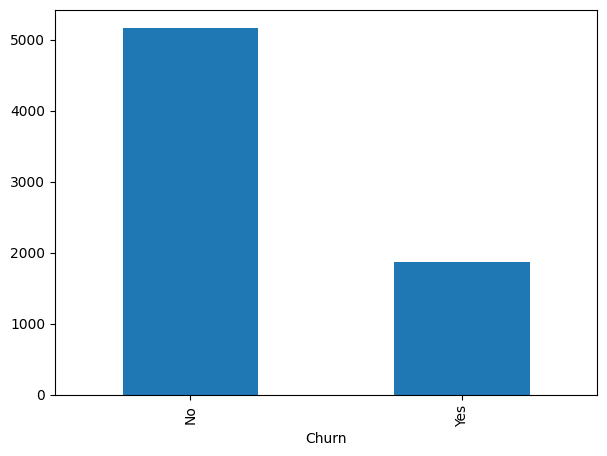

In [ ]:
df["Churn"].value_counts().plot(kind="bar", figsize=(7, 5))

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.groupby('PaperlessBilling')['Churn'].count()

,Churn
PaperlessBilling,
No,2864
Yes,4168


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.groupby('PaymentMethod')['Churn'].count()

,Churn
PaymentMethod,
Bank transfer (automatic),1542
Credit card (automatic),1521
Electronic check,2365
Mailed check,1604


In [ ]:
from sklearn.model_selection import train_test_split
X=df.drop('Churn',axis=1)
y=df['Churn']
X_test,X_train,y_test,y_train=train_test_split(X,y,test_size=0.2,random_state=42)


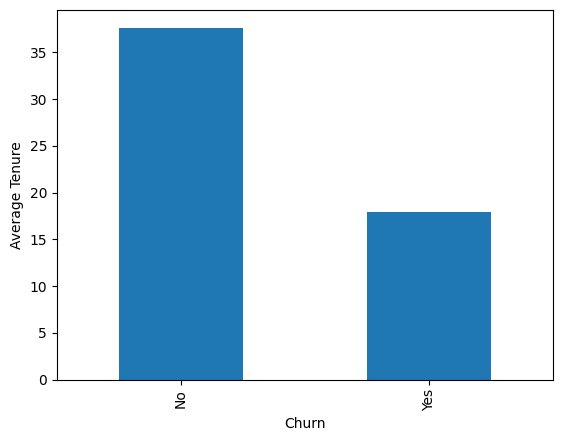

In [ ]:
import matplotlib.pyplot as plt

df.groupby("Churn")["tenure"].mean().plot(kind="bar")
plt.ylabel("Average Tenure")
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2481,Male,1,Yes,No,61,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.00,1501.75
6784,Female,0,No,No,19,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),24.70,465.85
6125,Male,0,Yes,No,13,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359
3052,Male,0,Yes,No,37,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Mailed check,55.05,2030.75
4099,Female,0,No,No,6,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),29.45,161.45


In [ ]:
transformer=ColumnTransformer(transformers=[
  ('tnf1',OneHotEncoder(sparse_output=False,drop='first'),['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']),
  ('tnf2',MinMaxScaler(),['tenure','MonthlyCharges','TotalCharges']),
],remainder='passthrough')

In [ ]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [ ]:
feature_names = transformer.get_feature_names_out()
print(feature_names)


['tnf1__gender_Male' 'tnf1__Partner_Yes' 'tnf1__Dependents_Yes'
 'tnf1__PhoneService_Yes' 'tnf1__MultipleLines_No phone service'
 'tnf1__MultipleLines_Yes' 'tnf1__InternetService_Fiber optic'
 'tnf1__InternetService_No' 'tnf1__OnlineSecurity_No internet service'
 'tnf1__OnlineSecurity_Yes' 'tnf1__OnlineBackup_No internet service'
 'tnf1__OnlineBackup_Yes' 'tnf1__DeviceProtection_No internet service'
 'tnf1__DeviceProtection_Yes' 'tnf1__TechSupport_No internet service'
 'tnf1__TechSupport_Yes' 'tnf1__StreamingTV_No internet service'
 'tnf1__StreamingTV_Yes' 'tnf1__StreamingMovies_No internet service'
 'tnf1__StreamingMovies_Yes' 'tnf1__Contract_One year'
 'tnf1__Contract_Two year' 'tnf1__PaperlessBilling_Yes'
 'tnf1__PaymentMethod_Credit card (automatic)'
 'tnf1__PaymentMethod_Electronic check' 'tnf1__PaymentMethod_Mailed check'
 'tnf2__tenure' 'tnf2__MonthlyCharges' 'tnf2__TotalCharges'
 'remainder__SeniorCitizen']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_transformed, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                                        Feature  Importance
28                           tnf2__TotalCharges    0.192151
26                                 tnf2__tenure    0.168191
27                         tnf2__MonthlyCharges    0.150874
24         tnf1__PaymentMethod_Electronic check    0.040818
6             tnf1__InternetService_Fiber optic    0.036121
21                      tnf1__Contract_Two year    0.034500
22                   tnf1__PaperlessBilling_Yes    0.032525
15                        tnf1__TechSupport_Yes    0.026024
0                             tnf1__gender_Male    0.025763
11                       tnf1__OnlineBackup_Yes    0.025374
5                       tnf1__MultipleLines_Yes    0.024115
1                             tnf1__Partner_Yes    0.023569
9                      tnf1__OnlineSecurity_Yes    0.023327
2                          tnf1__Dependents_Yes    0.021820
13                   tnf1__DeviceProtection_Yes    0.021777
29                     remainder__Senior

In [ ]:
y_pred=rf.predict(X_test_transformed)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7870222222222222

In [ ]:
lr=LogisticRegression()
lr.fit(X_train_transformed,y_train)

LogisticRegression()

In [ ]:
y_pred1=lr.predict(X_test_transformed)

In [ ]:
accuracy_score(y_test,y_pred1)

0.8024888888888889

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

          No       0.84      0.91      0.87      4130
         Yes       0.66      0.52      0.58      1495

    accuracy                           0.80      5625
   macro avg       0.75      0.71      0.73      5625
weighted avg       0.79      0.80      0.79      5625

